In [11]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [12]:
from fem import (
    # Core
    Material,
    # Sections
    Membrane,
    # Gmsh tools
    GMSHtools,
    # FEM builders
    plan, build_elements, build_load_vector,
    # Visualization — Gmsh
    add_element_data_view, add_node_data_view, compute_nodal_average,
    # Plotting — matplotlib
    plot_mesh, plot_field_2d, plot_deformed, plot_loads_2d, plot_gmsh_mesh,
    # Elements
    CST, LST, Quad4, Quad9,
    # Units
    kgf, tf, kN, MPa, GPa, kg, g, cm, m,
    # Parameters
    globalParameters,
)

import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh

np.set_printoptions(suppress=True, precision=6, linewidth=400)

In [13]:
globalParameters['nDoF'] = 2
globalParameters['nDIM'] = 2

In [14]:
# General model parameters

output_path = os.getcwd()
mesh_name = 'batman'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [15]:
# Define material
Steel = Material(name='Steel',
             E=200000.00, #Mpa
             nu=0.30,
             rho= 7850*kg/m**3*g*0)

# Sections
F1=Membrane(    name='F1',
                thickness=15,
                material=Steel)

# Dictionaries
section_dictionary={17:F1,
                        }

restrain_dictionary={18:['r', 'f']}

load_dictionary = {
                19:   {'value': 100/15, 'direction': 'x'},   
                20:   {'value': 100/15, 'direction': '-x'},   

}

In [16]:
# Read mesh
mesh = GMSHtools(output_file)
node_map, system_nDof = plan(mesh, restrain_dictionary)


  MESH SUMMARY

  === NODES ===  (2681 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1        -1.0000         1.0000         0.0000
       2        -0.7500         3.0000         0.0000
       3        -0.5000         2.2500         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (4 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
      18      0   'support'
      19      1   'load_p_x'
      20      1   'load_m_x'
      17      2   'steel'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (4 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
      18      0       15          1            2   'su

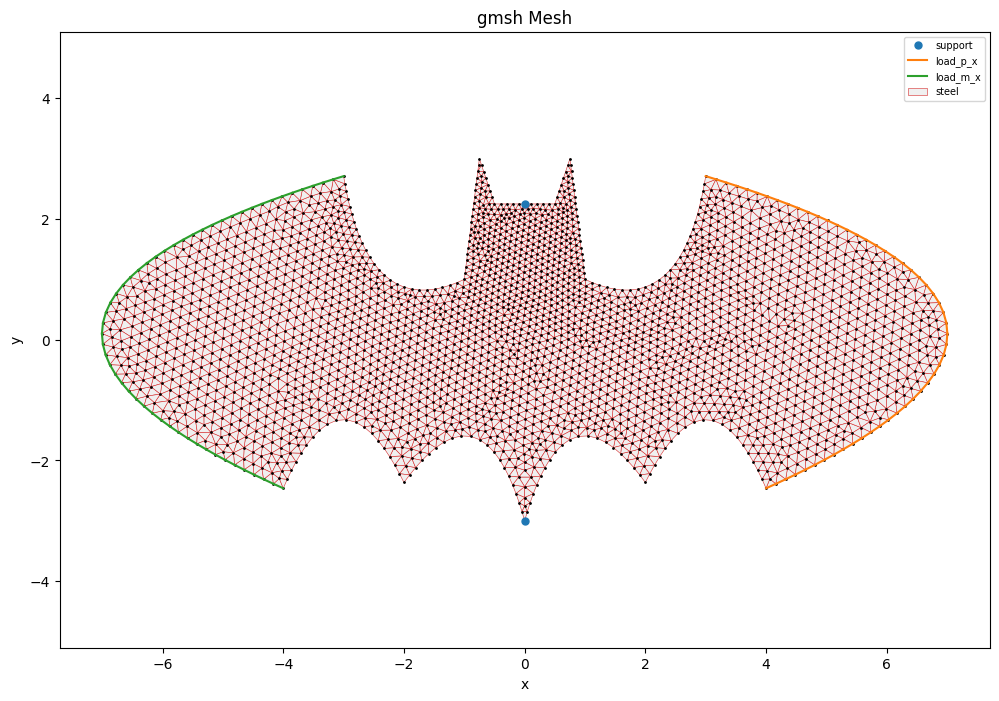

In [17]:
# %matplotlib widge
plot_gmsh_mesh(mesh,
               show_node_labels   = False,
               show_element_labels= False,
               show_node_points   = True,
            #    view_3d            = True,   elev= 45, azim= -45,
               figsize            = (12, 8))

In [18]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

elements = build_elements(
    mesh               = mesh,
    node_map           = node_map,
    section_dictionary = section_dictionary,
    element_class_map  = element_map,
    load_dictionary    = load_dictionary,
    type               = 'planeStrain',
    sampling_points    = 3,
    eval_points        = [0, 0],
)

In [19]:
# Build global nodal force vector from load dictionary = body + surface
F_load = np.zeros(system_nDof)
for elem in elements:
    F_load[elem.idx] += elem.F_fe_global

F_load += build_load_vector(mesh, node_map, load_dictionary, system_nDof)

In [20]:
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Assembly
K = lil_matrix((system_nDof, system_nDof))
for element in elements:
    for i_local, i_global in enumerate(element.idx):
        for j_local, j_global in enumerate(element.idx):
            K[i_global, j_global] += element.kg[i_local, j_local]
K = K.tocsr()

# Force vector
F = np.zeros(system_nDof)
for node in node_map.values():
    F[node.idx] += node.nodalLoad
F += F_load

# DOF classification
dof_flags       = np.concatenate([node.restrain for node in node_map.values()])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

# Partitioning
Kff = K[free_dofs[:, None], free_dofs]
Kfr = K[free_dofs[:, None], restrained_dofs]
Krf = K[restrained_dofs[:, None], free_dofs]
Krr = K[restrained_dofs[:, None], restrained_dofs]

# Solution
ur = np.zeros(len(restrained_dofs))
uf = spsolve(Kff, F[free_dofs] - Kfr @ ur)

u = np.zeros(system_nDof)
u[free_dofs]       = uf
u[restrained_dofs] = ur

# Reactions
Rr = Krf @ uf + Krr @ ur
R  = np.zeros(system_nDof)
R[restrained_dofs] = Rr

In [21]:
# Reactions per node
for node in node_map.values():
    if any(r == 'r' for r in node.restrain):
        r = R[node.idx]
        print(f"Node {node.name}:  Rx={r[0]:+.6f}  Ry={r[1]:+.6f}")

# Equilibrium check
total_applied_x  = np.sum(F[0::2])
total_applied_y  = np.sum(F[1::2])
total_reaction_x = np.sum(R[0::2])
total_reaction_y = np.sum(R[1::2])
print('--' * 50)
print(f"Applied X:  {total_applied_x:+.4f}   Reaction X: {total_reaction_x:+.4f}   Balance: {total_applied_x + total_reaction_x:.4e}")
print(f"Applied Y:  {total_applied_y:+.4f}   Reaction Y: {total_reaction_y:+.4f}   Balance: {total_applied_y + total_reaction_y:.4e}")

Node 4:  Rx=+0.000000  Ry=+0.000000
Node 9:  Rx=-0.000000  Ry=+0.000000
----------------------------------------------------------------------------------------------------
Applied X:  +0.0000   Reaction X: +0.0000   Balance: 9.3965e-11
Applied Y:  +0.0000   Reaction Y: +0.0000   Balance: 1.1933e-13


In [23]:
for node in node_map.values():
    fx = F_load[node.idx[0]]
    fy = F_load[node.idx[1]]
    if abs(fx) > 0 or abs(fy) > 0:
        print(f"Node {node.name} at {node.coordinates}:  Fx={fx:+.4f}  Fy={fy:+.4f}")

Node 11 at [-4.       -2.461955]:  Fx=-9.5550  Fy=+0.0000
Node 12 at [ 4.       -2.461955]:  Fx=+9.5550  Fy=+0.0000
Node 13 at [-3.        2.710524]:  Fx=-9.5550  Fy=+0.0000
Node 14 at [3.       2.710524]:  Fx=+9.5550  Fy=+0.0000
Node 71 at [-2.978307  2.583487]:  Fx=+0.0000  Fy=-0.0000
Node 118 at [2.978307 2.583487]:  Fx=-0.0000  Fy=+0.0000
Node 119 at [-3.171265  2.657935]:  Fx=-19.1099  Fy=+0.0000
Node 120 at [-3.342141  2.604105]:  Fx=-19.1100  Fy=+0.0000
Node 121 at [-3.512599  2.548956]:  Fx=-19.1099  Fy=+0.0000
Node 122 at [-3.682593  2.492408]:  Fx=-19.1098  Fy=+0.0000
Node 123 at [-3.852086  2.434365]:  Fx=-19.1099  Fy=+0.0000
Node 124 at [-4.021023  2.374727]:  Fx=-19.1099  Fy=+0.0000
Node 125 at [-4.189349  2.31338 ]:  Fx=-19.1100  Fy=+0.0000
Node 126 at [-4.356992  2.250196]:  Fx=-19.1098  Fy=+0.0000
Node 127 at [-4.523875  2.185035]:  Fx=-19.1098  Fy=+0.0000
Node 128 at [-4.689908  2.117731]:  Fx=-19.1098  Fy=+0.0000
Node 129 at [-4.854978  2.048104]:  Fx=-19.1097  Fy=+0.

In [24]:
n_nodes    = len(node_map)
n_elements = len(elements)

# Prepare displacement, force and reaction arrays (3D format for Gmsh)
u_3d = np.zeros((n_nodes, 3))
F_3d = np.zeros((n_nodes, 3))
R_3d = np.zeros((n_nodes, 3))

for i, node in enumerate(node_map.values()):
    u_3d[i, 0] = u[node.idx[0]]
    u_3d[i, 1] = u[node.idx[1]]
    F_3d[i, 0] = F[node.idx[0]]
    F_3d[i, 1] = F[node.idx[1]]
    R_3d[i, 0] = R[node.idx[0]]
    R_3d[i, 1] = R[node.idx[1]]

# Node tags for Gmsh
node_tags = np.array([node.name for node in node_map.values()])

# Stress, strain and Von Mises
sigma_gmsh             = np.zeros((n_elements, 3))
epsilon_gmsh           = np.zeros((n_elements, 3))
sigma_principal_gmsh   = np.zeros((n_elements, 2))
epsilon_principal_gmsh = np.zeros((n_elements, 2))
von_mises_gmsh         = np.zeros(n_elements)
element_tags_list      = []

for i, element in enumerate(elements):
    results = element.get_results(u)
    sigma   = results['stress'].flatten()
    epsilon = results['strain'].flatten()

    sigma_gmsh[i, :]             = sigma
    epsilon_gmsh[i, :]           = epsilon
    sigma_principal_gmsh[i, :]   = results['principal_stress'].flatten()
    epsilon_principal_gmsh[i, :] = results['principal_strain'].flatten()

    sxx, syy, sxy     = sigma
    von_mises_gmsh[i] = np.sqrt(sxx**2 - sxx*syy + syy**2)
    element_tags_list.append(element.element_tag)

In [26]:

# VISUALIZE RESULTS IN GMSH


gmsh.initialize()
gmsh.open(output_file)

# Node tags already computed above
# node_tags = np.array([node.name for node in nodes_list])

# --- Nodal vector fields ---
# VectorType options:
# 1 → Line segments (simple lines)
# 2 → Arrows
# 3 → Pyramids
# 4 → 3D arrows
# 5 → Displacement (visually deforms mesh)
# 6 → Displacement with deformation

add_node_data_view("Displacements",
                   node_tags,
                   u_3d,
                   vector_type=5,
                   factor=5)

add_node_data_view("Applied Loads",
                   node_tags,
                   F_3d,
                   arrow_size_max=60,
                   arrow_size_min=20)

add_node_data_view("Reactions",
                   node_tags,
                   R_3d)

2

In [27]:
# Hide surface faces for better visualization
gmsh.option.setNumber("Mesh.SurfaceFaces", 0)

# --- Element-based stress fields ---
add_element_data_view("Stress Sxx", 
                      element_tags_list, 
                      sigma_gmsh[:, 0])

add_element_data_view("Stress Syy", 
                      element_tags_list,
                        sigma_gmsh[:, 1])

add_element_data_view("Stress Sxy", 
                      element_tags_list, 
                      sigma_gmsh[:, 2])

# --- Element-based strain fields ---
add_element_data_view("Strain Exx", 
                      element_tags_list, 
                      epsilon_gmsh[:, 0])

add_element_data_view("Strain Eyy", 
                      element_tags_list, 
                      epsilon_gmsh[:, 1])

add_element_data_view("Strain Exy",
                      element_tags_list, 
                      epsilon_gmsh[:, 2])

8

In [28]:
# --- Principal stresses ---
add_element_data_view("Principal Stress S1", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 0])

add_element_data_view("Principal Stress S2", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 1])

# --- Principal strains ---
add_element_data_view("Principal Strain E1", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 0])

add_element_data_view("Principal Strain E2", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 1])

12

In [29]:
# --- Von Mises stress ---
add_element_data_view("Von Mises Stress", 
                      element_tags_list, 
                      von_mises_gmsh)

13

In [31]:
# --- Nodal averaged stress fields ---
sxx_nodal = compute_nodal_average(elements, 
                                sigma_gmsh[:, 0],   
                                node_map.values())
add_node_data_view("Sxx Nodal Averaged",                 
                    node_tags, sxx_nodal)

# -----------------
syy_nodal = compute_nodal_average(elements, 
                                sigma_gmsh[:, 1],   
                                node_map.values())
add_node_data_view("Syy Nodal Averaged",                 
                    node_tags, syy_nodal)

# -----------------
sxy_nodal = compute_nodal_average(elements, 
                                sigma_gmsh[:, 2],   
                                node_map.values())
add_node_data_view("Sxy Nodal Averaged",                 
                    node_tags, sxy_nodal)

# -----------------
s1_nodal = compute_nodal_average(elements, 
                                sigma_principal_gmsh[:, 0],     
                                node_map.values())
add_node_data_view("Principal Stress S1 Nodal Averaged",
                     node_tags, s1_nodal)

# -----------------
s2_nodal = compute_nodal_average(elements, 
                                sigma_principal_gmsh[:, 1],     
                                node_map.values())
add_node_data_view("Principal Stress S2 Nodal Averaged",
                     node_tags, s2_nodal)

# -----------------
vm_nodal = compute_nodal_average(elements, 
                                von_mises_gmsh,     
                                node_map.values())
add_node_data_view("Von Mises Nodal Averaged",          
                     node_tags, vm_nodal)

# -----------------
exx_nodal = compute_nodal_average(elements, 
                                epsilon_gmsh[:, 0],     
                                node_map.values())
add_node_data_view("Strain Exx Averaged",                
                    node_tags, exx_nodal)

# -----------------
# Open Gmsh GUI
gmsh.fltk.run()
gmsh.finalize()

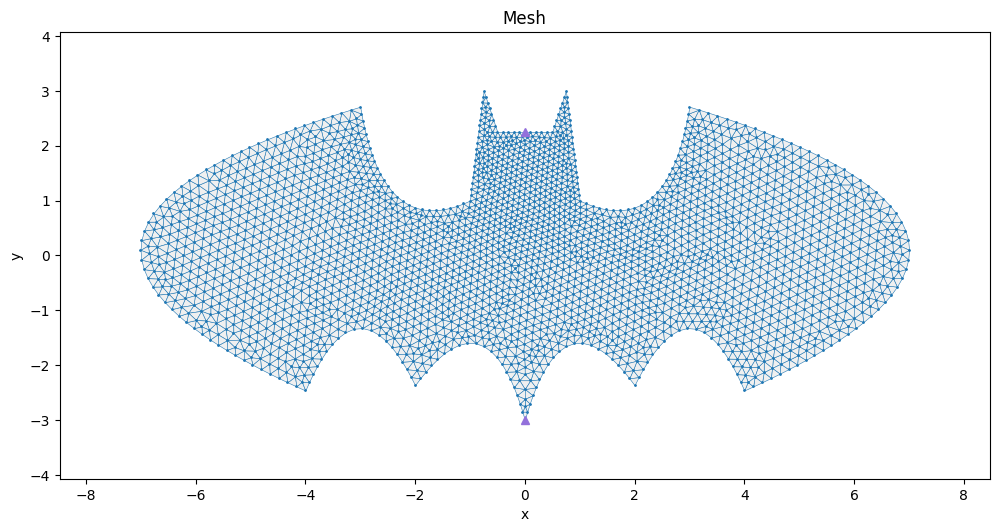

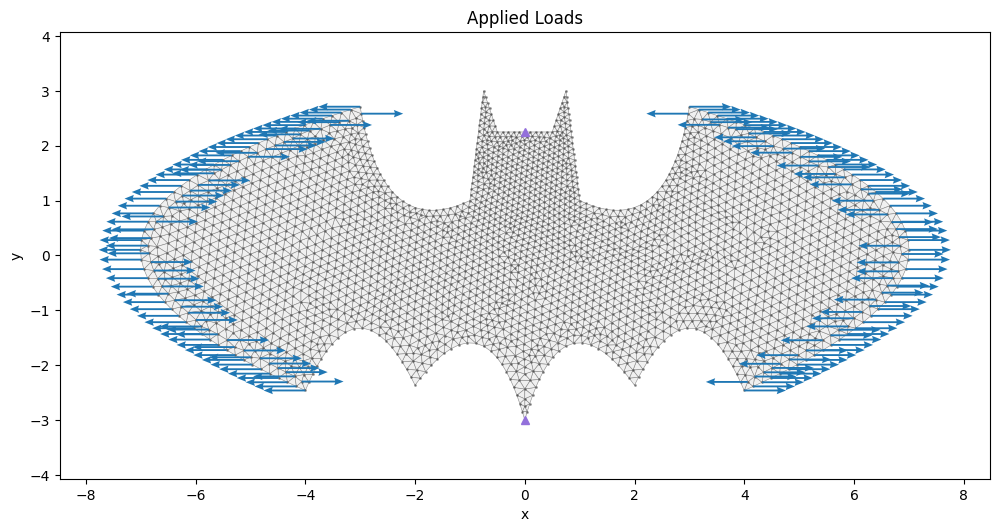

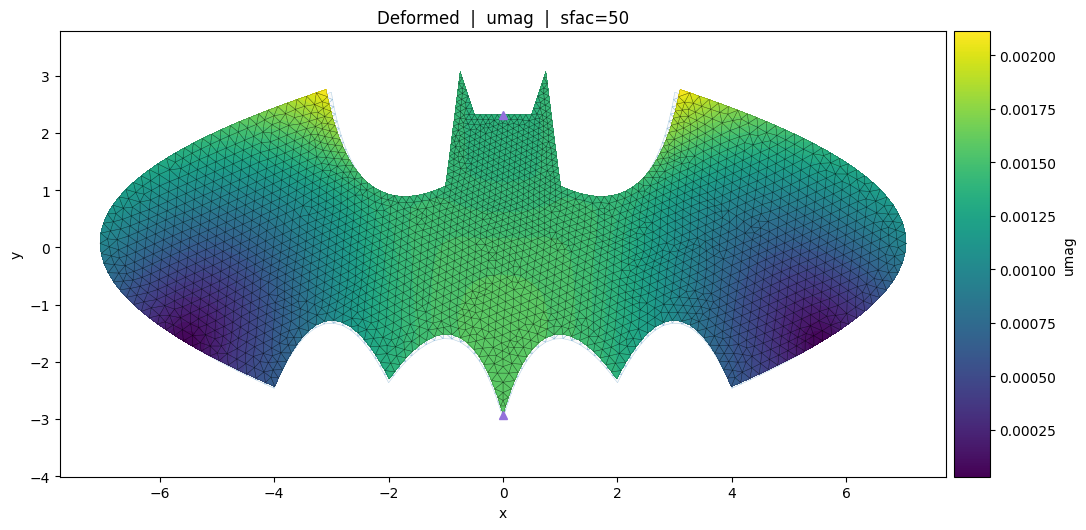

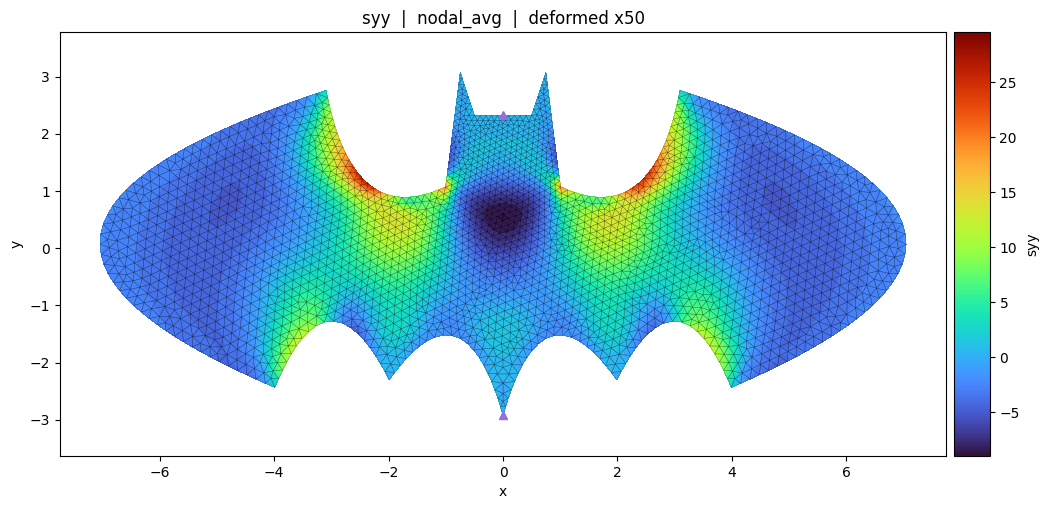

In [34]:
# Mesh
plot_mesh(
    nodes               = node_map.values(),
    elements            = elements,
    show_node_labels    = False,
    show_element_labels = False,
    show_supports       = True,
    show_element_edges  = True,
    show_node_points    = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Loads
plot_loads_2d(
    nodes               = node_map.values(),
    elements            = elements,
    F_load              = F_load,
    show_element_edges  = True,
    show_node_points    = True,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Deformed
plot_deformed(
    nodes               = node_map.values(),
    elements            = elements,
    u                   = u,
    component           = 'umag',   # 'ux', 'uy', 'umag'
    sfac                = 50,
    cmap                = 'viridis',
    limit               = None,
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Stress or Strain Field
plot_field_2d(
    nodes               = node_map.values(),
    elements            = elements,
    u                   = u,
    component           = 'syy',       # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy','e1','e2'
    result_type         = 'nodal_avg', # 'nodal_avg' or 'element'
    deformed            = True,
    sfac                = 50,
    limit               = None,
    cmap                = 'turbo',
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)